# ER-2 planned vs. flown — Green Card / KML / IWG1 comparison

Three-way comparison between a NASA ER-2 mission's *planned* product (KML route + Green Card mission data card), the *as-flown* IWG1 in-situ recording, and HyPlan's *modeled* trajectory built from the calibrated [`NASA_ER2()`](../../hyplan/aircraft/_models.py).

This notebook focuses on the **NM17 B** pair (planned 04/19, flown 2026-04-19). CO06 / CO07v4 have PDF Green Cards and will be added once the PDF parser lands; see [PAIRS.md](PAIRS.md) for the full pair table.

Pipeline:

1. `load_planned_sortie(kml, gc)` → ordered planned-event table + header.
2. `load_iwg1(path)` + `trim_ground_taxi` → as-flown trace.
3. Mission-level summary (planned vs. flown total / TOC / on-station / descent).
4. Fix-by-fix comparison at numbered waypoints.
5. Top-of-climb / top-of-descent location and timing.
6. Side-by-side ground-track and altitude-profile plots.

Step-cruise structural notes (single-altitude `FlightLine` representation)

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from pathlib import Path
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import LineString
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from hyplan import initialize_data
from hyplan.aircraft import (
    load_iwg1, trim_ground_taxi, load_planned_sortie,
)

DATA_DIR = Path("../../data/er2").resolve()

# NM17 B pair (see PAIRS.md). Swap to other pairs once their parsers land.
PLANNED_NAME = "NM17 B"
PLANNED_KML  = DATA_DIR / "NM17 B KML.kml"
PLANNED_GC   = DATA_DIR / "NM17 B ER2 Green Card1.xlsx"
FLOWN_IWG1   = DATA_DIR / "69e4e6e92706ae3e20f884fd.txt"
MIN_CRUISE_ALT_FT = 50_000

initialize_data(countries=["US"])
print(f"pair: {PLANNED_NAME}")
print(f"  KML : {PLANNED_KML.name}")
print(f"  GC  : {PLANNED_GC.name}")
print(f"  IWG1: {FLOWN_IWG1.name}")

pair: NM17 B
  KML : NM17 B KML.kml
  GC  : NM17 B ER2 Green Card1.xlsx
  IWG1: 69e4e6e92706ae3e20f884fd.txt


## 1. Load the planned sortie

Header carries the mission identity, schedule, and fuel state. The waypoint table has one row per planned event — numbered waypoints plus inline `.level off` / `.delay` / `.descent pt` sub-rows.

In [2]:
planned = load_planned_sortie(PLANNED_KML, PLANNED_GC)
for k, v in planned.header.items():
    print(f"  {k:24s} {v}")
print()
print(f"events: {len(planned.waypoints):d}  (counts by kind: {dict(planned.waypoints['kind'].value_counts())})")
planned.waypoints[[
    "order", "wp_num", "fix_name", "kind", "lat_deg", "lon_deg",
    "altitude_ft", "leg_time_min", "cumulative_time_min", "tas_kt",
]].head(10)

  aircraft_id              NASA806
  mission_name             GEMX
  sched_takeoff_z          15:30:00
  takeoff_time_z           15:30:00
  land_time_z              22:03:35
  sched_duration_hours     6.559722222222222
  fuel_load_lb             1853
  fuel_used_lb             1332

events: 44  (counts by kind: {'waypoint': np.int64(38), 'level_off': np.int64(2), 'delay': np.int64(2), 'descent_pt': np.int64(2)})


,order,wp_num,fix_name,kind,lat_deg,lon_deg,altitude_ft,leg_time_min,cumulative_time_min,tas_kt
0,1,1.0,KCOS/A,waypoint,38.805833,-104.700833,6187.0,0.0,0.0,NaN
1,2,2.0,BRK/E,waypoint,38.944500,-104.633500,23990.0,3.4,3.4,NaN
2,3,NaN,.level off,level_off,38.924500,-104.634833,26000.0,0.4,3.8,NaN
3,4,3.0,PUB/R253012,waypoint,38.262667,-104.680333,26000.0,7.0,10.8,328.0
4,5,4.0,PUB/R206014,waypoint,38.093333,-104.600167,35578.0,2.5,13.3,NaN
5,6,NaN,.delay,delay,38.093333,-104.600167,61186.0,25.0,38.3,NaN
6,7,NaN,.level off,level_off,37.148833,-104.174333,65000.0,9.0,47.3,NaN
7,8,5.0,TBE/E245028,waypoint,37.148833,-104.174333,65000.0,0.1,47.4,683.0
8,9,6.0,M251N/L,waypoint,37.085167,-104.168333,65000.0,0.6,48.0,396.0
9,10,7.0,M251S/L,waypoint,34.463833,-104.168333,65000.0,23.9,71.9,395.0


## 2. Load the matched as-flown sortie

Same `load_iwg1` + `trim_ground_taxi` pipeline used in [sortie_replay.ipynb](sortie_replay.ipynb). The inline `label_phases` is the simple VS-threshold classifier from `iwg1_calibration.ipynb`.

In [3]:
def label_phases(df, climb_fpm=300.0, descent_fpm=-300.0, min_seconds=60.0):
    df = df.copy()
    df["phase"] = "cruise"
    df.loc[df["vertical_rate"] >= climb_fpm, "phase"] = "climb"
    df.loc[df["vertical_rate"] <= descent_fpm, "phase"] = "descent"
    t = (df["timestamp"] - df["timestamp"].iloc[0]).dt.total_seconds().to_numpy()
    phases = df["phase"].to_numpy()
    if len(phases) < 2: return df
    runs, start = [], 0
    for i in range(1, len(phases) + 1):
        if i == len(phases) or phases[i] != phases[start]:
            runs.append((start, i, phases[start])); start = i
    out = phases.copy()
    for s, e, _ in runs:
        if e - s == 0: continue
        duration = (t[e - 1] - t[s]) if e - 1 > s else 0
        if duration < min_seconds:
            prev_p = out[s - 1] if s > 0 else None
            next_p = out[e] if e < len(out) else None
            replacement = prev_p if prev_p is not None else next_p
            if replacement is not None:
                out[s:e] = replacement
    df["phase"] = out
    return df

raw = load_iwg1(FLOWN_IWG1)
actual = trim_ground_taxi(raw)
actual = label_phases(actual)
actual_takeoff = actual["timestamp"].iloc[0]
actual_landing = actual["timestamp"].iloc[-1]
actual_total_min = (actual_landing - actual_takeoff).total_seconds() / 60.0
actual_max_alt_ft = float(actual["altitude"].max())
print(f"sortie date         : {actual_takeoff.strftime('%Y-%m-%d')}")
print(f"airborne fixes      : {len(actual):>5d}")
print(f"actual takeoff (Z)  : {actual_takeoff.strftime('%H:%M:%S')}")
print(f"actual landing (Z)  : {actual_landing.strftime('%H:%M:%S')}")
print(f"total duration      : {actual_total_min:.1f} min")
print(f"max altitude        : {actual_max_alt_ft:.0f} ft")

sortie date         : 2026-04-19
airborne fixes      :  4530
actual takeoff (Z)  : 15:26:07
actual landing (Z)  : 21:43:37
total duration      : 377.5 min
max altitude        : 65982 ft


## 3. Mission-level summary

Planned values come from the Green Card (cumulative time at the relevant boundary events). Flown values come from the IWG1 trace using the same boundary definitions used by [sortie_replay.ipynb](sortie_replay.ipynb): TOC = first fix at ≥ `MIN_CRUISE_ALT_FT`, TOD = last such fix, on-station = cruise-phase fixes ≥ `MIN_CRUISE_ALT_FT`.

In [4]:
df = planned.waypoints

# Planned TOC: linear interpolation across the planned events on
# (cumulative_time_min, altitude_ft) to find the time when altitude
# first reaches MIN_CRUISE_ALT_FT.  ER-2 plans climb in steps with
# .level off events, so the trace is monotonic during the climb phase.
alt = df["altitude_ft"].to_numpy()
ct = df["cumulative_time_min"].to_numpy()
above = alt >= MIN_CRUISE_ALT_FT
first_high = int(np.argmax(above)) if above.any() else None
last_high  = int(len(above) - 1 - np.argmax(above[::-1])) if above.any() else None
if first_high is not None and first_high > 0:
    a0, a1 = alt[first_high - 1], alt[first_high]
    t0, t1 = ct[first_high - 1], ct[first_high]
    frac = (MIN_CRUISE_ALT_FT - a0) / (a1 - a0) if a1 != a0 else 0.0
    planned_toc_min = t0 + frac * (t1 - t0)
else:
    planned_toc_min = float("nan")
if last_high is not None and last_high < len(alt) - 1:
    a0, a1 = alt[last_high], alt[last_high + 1]
    t0, t1 = ct[last_high], ct[last_high + 1]
    frac = (MIN_CRUISE_ALT_FT - a0) / (a1 - a0) if a1 != a0 else 0.0
    planned_tod_min = t0 + frac * (t1 - t0)
else:
    planned_tod_min = float("nan")
planned_total_min = float(df["cumulative_time_min"].iloc[-1])
planned_on_station_min = planned_tod_min - planned_toc_min
planned_descent_min = planned_total_min - planned_tod_min

# Flown side
above_a = (actual["altitude"] >= MIN_CRUISE_ALT_FT)
in_high = above_a & (actual["phase"] == "cruise")
fhi = above_a.idxmax() if above_a.any() else None
lhi = above_a[::-1].idxmax() if above_a.any() else None
actual_toc_min = ((actual.loc[fhi, "timestamp"] - actual_takeoff).total_seconds() / 60.0
                  if fhi is not None else float("nan"))
actual_tod_min = ((actual.loc[lhi, "timestamp"] - actual_takeoff).total_seconds() / 60.0
                  if lhi is not None else float("nan"))
actual_on_station_min = actual_tod_min - actual_toc_min
actual_descent_min = actual_total_min - actual_tod_min

summary = pd.DataFrame([
    {"metric": "total_duration_min",       "planned": round(planned_total_min, 1),       "flown": round(actual_total_min, 1)},
    {"metric": "time_to_cruise_min",       "planned": round(planned_toc_min, 1),         "flown": round(actual_toc_min, 1)},
    {"metric": "time_on_station_min",      "planned": round(planned_on_station_min, 1),  "flown": round(actual_on_station_min, 1)},
    {"metric": "descent_min",              "planned": round(planned_descent_min, 1),     "flown": round(actual_descent_min, 1)},
])
summary["delta_min"] = (summary["flown"] - summary["planned"]).round(1)
summary["pct"] = (summary["delta_min"] / summary["planned"] * 100).round(1)
summary.set_index("metric")

,planned,flown,delta_min,pct
metric,,,,
total_duration_min,393.6,377.5,-16.1,-4.1
time_to_cruise_min,27.4,22.3,-5.1,-18.6
time_on_station_min,332.0,328.7,-3.3,-1.0
descent_min,34.2,26.5,-7.7,-22.5


## 4. Fix-by-fix comparison

Walk the numbered planned waypoints in order; for each, find the *next* IWG1 fix that comes within ~5 nmi of the planned lat/lon (sequential matching handles racetrack patterns where the aircraft passes over a fix multiple times). Compare planned ATA (cumulative time) vs. flown ATA at that fix; report altitude residual.

In [5]:
def _haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1r, lat2r = np.radians(lat1), np.radians(lat2)
    dlat = lat2r - lat1r
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1r) * np.cos(lat2r) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

MATCH_RADIUS_NMI = 5.0
MATCH_RADIUS_KM = MATCH_RADIUS_NMI * 1.852

wpts = planned.waypoints[planned.waypoints["kind"] == "waypoint"].reset_index(drop=True)
actual_lat = actual["latitude"].to_numpy()
actual_lon = actual["longitude"].to_numpy()
actual_alt = actual["altitude"].to_numpy()
actual_ts = actual["timestamp"].to_numpy()

rows = []
search_start = 0
for _, w in wpts.iterrows():
    if pd.isna(w["lat_deg"]) or pd.isna(w["lon_deg"]):
        continue
    d_km = _haversine_km(
        w["lat_deg"], w["lon_deg"],
        actual_lat[search_start:], actual_lon[search_start:],
    )
    in_range = d_km <= MATCH_RADIUS_KM
    if not in_range.any():
        rows.append({
            "wp_num": int(w["wp_num"]),
            "fix_name": w["fix_name"],
            "planned_ata_min": float(w["cumulative_time_min"]),
            "flown_ata_min": float("nan"),
            "delta_min": float("nan"),
            "planned_alt_ft": float(w["altitude_ft"]),
            "flown_alt_ft": float("nan"),
            "alt_delta_ft": float("nan"),
            "closest_dist_nmi": float(np.nanmin(d_km) / 1.852) if len(d_km) else float("nan"),
        })
        continue
    # Restrict to the *first contiguous in-range run* starting from
    # search_start; that's the time the aircraft actually passed over
    # this fix on this leg.  Subsequent revisits (racetracks, returns
    # to a fix on the way home) belong to later planned waypoints.
    first_in = int(np.argmax(in_range))
    out_idx = np.where(~in_range[first_in:])[0]
    end_of_run = first_in + int(out_idx[0]) if len(out_idx) else len(in_range)
    local_idx = first_in + int(np.argmin(d_km[first_in:end_of_run]))
    abs_idx = search_start + local_idx
    flown_t = (pd.Timestamp(actual_ts[abs_idx]) - actual_takeoff).total_seconds() / 60.0
    rows.append({
        "wp_num": int(w["wp_num"]),
        "fix_name": w["fix_name"],
        "planned_ata_min": float(w["cumulative_time_min"]),
        "flown_ata_min": round(flown_t, 1),
        "delta_min": round(flown_t - float(w["cumulative_time_min"]), 1),
        "planned_alt_ft": float(w["altitude_ft"]),
        "flown_alt_ft": round(float(actual_alt[abs_idx])),
        "alt_delta_ft": round(float(actual_alt[abs_idx] - w["altitude_ft"])),
        "closest_dist_nmi": round(float(d_km[local_idx]) / 1.852, 2),
    })
    # Advance the search window past the end of this in-range run so
    # the next planned waypoint matches a strictly later fix.
    search_start = search_start + end_of_run

fix_table = pd.DataFrame(rows)
matched = fix_table[fix_table["flown_ata_min"].notna()]
print(f"matched {len(matched)} of {len(fix_table)} numbered waypoints within {MATCH_RADIUS_NMI} nmi")
if len(matched):
    print(f"median |delta_min|:    {matched['delta_min'].abs().median():.1f} min")
    print(f"median |alt_delta_ft|: {matched['alt_delta_ft'].abs().median():.0f} ft")
fix_table

matched 36 of 38 numbered waypoints within 5.0 nmi
median |delta_min|:    3.1 min
median |alt_delta_ft|: 396 ft


,wp_num,fix_name,planned_ata_min,flown_ata_min,delta_min,planned_alt_ft,flown_alt_ft,alt_delta_ft,closest_dist_nmi
0,1,KCOS/A,0.0,0.2,0.2,6187.0,5830.0,-357.0,0.710000
1,2,BRK/E,3.4,NaN,NaN,23990.0,NaN,NaN,6.097904
2,3,PUB/R253012,10.8,13.8,2.9,26000.0,35860.0,9860.0,4.540000
3,4,PUB/R206014,13.3,29.3,16.0,35578.0,55818.0,20240.0,2.850000
4,5,TBE/E245028,47.4,45.8,-1.6,65000.0,63515.0,-1485.0,0.350000
5,6,M251N/L,48.0,46.6,-1.4,65000.0,63580.0,-1420.0,1.480000
6,7,M251S/L,71.9,69.7,-2.2,65000.0,65458.0,458.0,0.020000
7,8,CNX/R080052,76.2,74.0,-2.2,65000.0,64855.0,-145.0,0.840000
8,9,M245S/L,78.1,76.1,-2.0,65000.0,64572.0,-428.0,0.210000
9,10,M245N/L,102.0,99.6,-2.4,65000.0,65600.0,600.0,0.180000


## 5. Build a HyPlan flight plan from the planned sortie

Convert the parsed Green Card waypoints into the inputs `compute_flight_plan` accepts:

* **Detection rule (NM17 B and other observed ER-2 products):** every flight-line endpoint carries the `/L` suffix (`M251N/L`, `T643S/L`, …). Pairs of consecutive `/L` waypoints define one `FlightLine`. The non-`/L` waypoints between them (`CNX/R080052`, `CIM/R348042`, `TBE/Exxx`, `CVS/Txxx`) are stand-ins for the planner's Dubins turns and are dropped — HyPlan generates its own.
* **Climb-out / descent-in connectors** (the named navaid hops at the head and tail, plus `.level off`, `.delay`, `.descent pt` sub-rows) are also dropped. HyPlan's `compute_flight_plan` derives those from the takeoff and return airports plus the calibrated [`NASA_ER2()`](../../hyplan/aircraft/_models.py) climb / descent profiles.
* **Departure / arrival airports** come from the first / last `/A`-suffixed waypoints (here both `KCOS`).
* **Per-line altitude:** the Green Card altitude is taken verbatim from the first endpoint of each pair (both endpoints share the same altitude on every NM17 B line).

This logic is intentionally kept in the notebook so the rule can be tweaked per pair without touching `hyplan/aircraft/`.

In [6]:
from hyplan import FlightLine, Airport, NASA_ER2, compute_flight_plan
from hyplan.units import ureg


def _line_id(name_a: str, name_b: str) -> str:
    """Longest common prefix of two `/L`-stripped fix names.

    `M251N/L` + `M251S/L` → `M251`; falls back to ``A_to_B`` when no
    prefix is shared.
    """
    a = name_a.removesuffix("/L")
    b = name_b.removesuffix("/L")
    n = 0
    while n < min(len(a), len(b)) and a[n] == b[n]:
        n += 1
    common = a[:n].rstrip("/-_")
    return common or f"{a}_to_{b}"


def _vector_mean_wind(speed_kt, direction_deg):
    """Vector mean of a wind series.

    Inputs are met-convention "from" (deg true) and knots. Returns
    ``(mean_speed_kt, mean_direction_deg)`` in the same convention,
    handling 0/360 wrap correctly.
    """
    s = speed_kt.dropna()
    d = direction_deg.loc[s.index].dropna()
    common = s.index.intersection(d.index)
    s, d = s.loc[common], d.loc[common]
    u = -s * np.sin(np.radians(d))   # eastward component
    v = -s * np.cos(np.radians(d))   # northward component
    um, vm = u.mean(), v.mean()
    mean_speed = float(np.hypot(um, vm))
    mean_dir = float(np.degrees(np.arctan2(-um, -vm)) % 360.0)
    return mean_speed, mean_dir


# 1. Extract the /L pairs as FlightLines.
endpoints = (
    planned.waypoints[planned.waypoints["fix_name"].str.endswith("/L")]
    .reset_index(drop=True)
)
if len(endpoints) % 2 != 0:
    raise ValueError(
        f"odd number of /L endpoints ({len(endpoints)}) — manual inspection needed"
    )

flight_lines = []
for i in range(0, len(endpoints), 2):
    a = endpoints.iloc[i]
    b = endpoints.iloc[i + 1]
    if a["altitude_ft"] != b["altitude_ft"]:
        # Per-line altitude differs between endpoints — surfaces step-cruise
        # planning on a single line.  Take the start-endpoint altitude.
        print(f"  warning: altitude mismatch on line {a['fix_name']}↔{b['fix_name']} "
              f"({a['altitude_ft']}→{b['altitude_ft']} ft); using start altitude")
    flight_lines.append(FlightLine.from_endpoints(
        lat1=float(a["lat_deg"]), lon1=float(a["lon_deg"]),
        lat2=float(b["lat_deg"]), lon2=float(b["lon_deg"]),
        altitude_msl=ureg.Quantity(float(a["altitude_ft"]), "feet"),
        site_name=_line_id(a["fix_name"], b["fix_name"]),
    ))

# 2. Departure / arrival airports (first / last /A waypoint).
airport_rows = planned.waypoints[planned.waypoints["fix_name"].str.endswith("/A")]
dep_icao = airport_rows.iloc[0]["fix_name"].removesuffix("/A")
arr_icao = airport_rows.iloc[-1]["fix_name"].removesuffix("/A")
departure = Airport(dep_icao)
arrival = Airport(arr_icao)

# 3. Constant wind field — cruise-mean (≥ MIN_CRUISE_ALT_FT, level flight)
# from the matched IWG1 trace.  This is the closest single-vector
# approximation of the winds the aircraft actually flew through.
cruise_mask = (
    (actual["altitude"] >= MIN_CRUISE_ALT_FT)
    & (actual["vertical_rate"].between(-300, 300))
)
mean_wind_kt, mean_wind_dir = _vector_mean_wind(
    actual.loc[cruise_mask, "wind_speed_kt"],
    actual.loc[cruise_mask, "wind_direction_deg"],
)
print(f"constant wind field (cruise mean from IWG1)")
print(f"  speed     : {mean_wind_kt:.1f} kt")
print(f"  direction : {mean_wind_dir:.0f}° (from)")
print()

# 4. Build the HyPlan plan.  start_offset / end_offset are 0 so modeled
# racetrack turns sit at the planned line endpoints (the default 5 nmi
# pre-extension would otherwise stretch each turn loop).  Turn radius
# now comes from `bank_by_phase` (cruise=20° for NASA_ER2 from IWG1
# calibration; see hyplan/aircraft/_models.py) — no per-aircraft
# override needed.
aircraft = NASA_ER2()

hyplan_plan_stillair = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0,
)
hyplan_plan = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0,
    wind_speed=mean_wind_kt * ureg.knot,
    wind_direction=mean_wind_dir,
)

bp = aircraft.turn_model.bank_by_phase
print(f"departure / arrival     : {dep_icao} / {arr_icao}")
print(f"flight lines            : {len(flight_lines)}")
print(f"bank_by_phase           : climb={bp.climb_deg}°  cruise={bp.cruise_deg}°  "
      f"descent={bp.descent_deg}°  approach={bp.approach_deg}°")
print(f"plan segments           : {len(hyplan_plan)}")
print(f"hyplan still-air total  : {hyplan_plan_stillair['time_to_segment'].sum():.1f} min")
print(f"hyplan wind-corrected   : {hyplan_plan['time_to_segment'].sum():.1f} min")
print(f"flown total             : {actual_total_min:.1f} min")
print(f"planned total           : {planned_total_min:.1f} min")
print()
fl_summary = pd.DataFrame([
    {
        "site": fl.site_name,
        "start": f"{fl.waypoint1.latitude:.3f},{fl.waypoint1.longitude:.3f}",
        "end":   f"{fl.waypoint2.latitude:.3f},{fl.waypoint2.longitude:.3f}",
        "length_nmi": fl.length.m_as(ureg.nautical_mile),
        "altitude_ft": fl.altitude_msl.m_as(ureg.foot),
    }
    for fl in flight_lines
])
fl_summary["length_nmi"] = fl_summary["length_nmi"].round(1)
fl_summary["altitude_ft"] = fl_summary["altitude_ft"].round().astype(int)
fl_summary

constant wind field (cruise mean from IWG1)
  speed     : 26.1 kt
  direction : 272° (from)



departure / arrival     : KCOS / KCOS
flight lines            : 10
bank_by_phase           : climb=11.0°  cruise=20.0°  descent=16.0°  approach=9.0°
plan segments           : 24
hyplan still-air total  : 380.2 min
hyplan wind-corrected   : 385.4 min
flown total             : 377.5 min
planned total           : 393.6 min



,site,start,end,length_nmi,altitude_ft
0,M251,"37.085,-104.168","34.464,-104.168",157.0,65000
1,M245,"34.464,-104.760","37.085,-104.760",157.0,65000
2,M246,"37.085,-104.660","34.464,-104.660",157.0,65000
3,M247,"34.464,-104.561","37.085,-104.561",157.0,65000
4,M248,"37.085,-104.462","34.464,-104.462",157.0,65000
5,M249,"34.464,-104.365","37.085,-104.365",157.0,65000
6,M250,"37.085,-104.267","34.464,-104.267",157.0,65000
7,M252,"34.464,-104.069","37.085,-104.069",157.0,65000
8,M253,"37.085,-103.970","34.464,-103.970",157.0,65000
9,T643,"34.468,-104.559","37.311,-103.429",179.0,65000


## 6. Altitude-resolved wind from the IWG1 trace itself

The constant-wind plan in §5 applies the same 26 kt @ 272° to every segment, including the takeoff climb-out at 6,000 ft and the approach at 9,000 ft where surface winds are usually a fraction of FL650 jetstream-edge values. That over-estimates wind drag on the climb / approach segments.

`compute_flight_plan` accepts a `wind_source: WindField` argument that the engine queries per segment — `wind_source.wind_at(lat, lon, altitude, segment_time)`. Out-of-the-box providers include `MERRA2WindField` / `GMAOWindField` / `GFSWindField`, but for replay the cleanest source is the IWG1 trace itself: it carries measured `(speed, direction)` at every fix. The class below wraps the trace as a `WindField` so HyPlan flies through the same wind the real aircraft did — sampled by nearest fix in `(lat, lon, altitude)` space, no external API call required.

In [7]:
from hyplan.winds import WindField


class IWG1TraceWindField(WindField):
    """`WindField` backed by an IWG1 trace.

    Returns the measured wind at the nearest IWG1 fix in
    ``(lat, lon, altitude)`` space.  The `time` argument is accepted
    (and ignored) so the engine's gridded-wind interface still works;
    nearest-in-space is sufficient when the modeled trajectory and the
    actual sortie share the same flight grid (the typical replay case).

    The lat/lon distance contribution uses nautical miles (1° lat ≈ 60
    nmi); altitude error contributes via a 100 ft / nmi penalty so a
    1,000 ft altitude error is weighted the same as 10 nmi of horizontal
    error.  That biases the lookup toward fixes at the same flight
    level, which is the right behavior for a step-cruise sortie where
    different flight lines fly at different altitudes.
    """

    _M_PER_S_PER_KT = 0.514444

    def __init__(self, iwg1_df):
        s_mps = iwg1_df["wind_speed_kt"].astype(float) * self._M_PER_S_PER_KT
        d_rad = np.radians(iwg1_df["wind_direction_deg"].astype(float))
        u = -s_mps * np.sin(d_rad)
        v = -s_mps * np.cos(d_rad)
        valid = (
            (~u.isna()) & (~v.isna())
            & (~iwg1_df["altitude"].isna())
            & (~iwg1_df["latitude"].isna())
            & (~iwg1_df["longitude"].isna())
        )
        df = iwg1_df.loc[valid]
        self._u = u[valid].to_numpy()
        self._v = v[valid].to_numpy()
        self._lat = df["latitude"].to_numpy()
        self._lon = df["longitude"].to_numpy()
        self._alt_ft = df["altitude"].to_numpy()
        self._n = len(self._u)

    def wind_at(self, lat, lon, altitude, time=None):
        alt_ft = altitude.m_as("feet")
        lat_cos = np.cos(np.radians(lat))
        d2 = ((self._lat - lat) * 60.0) ** 2
        d2 += ((self._lon - lon) * 60.0 * lat_cos) ** 2
        d2 += ((self._alt_ft - alt_ft) / 100.0) ** 2
        idx = int(np.argmin(d2))
        return (
            float(self._u[idx]) * (ureg.meter / ureg.second),
            float(self._v[idx]) * (ureg.meter / ureg.second),
        )


iwg1_wind = IWG1TraceWindField(actual)
print(f"IWG1TraceWindField built from {iwg1_wind._n} measured fixes "
      f"({len(actual) - iwg1_wind._n} dropped for NaN)")
print(f"  altitude range : {iwg1_wind._alt_ft.min():.0f} – {iwg1_wind._alt_ft.max():.0f} ft")
print(f"  lat range      : {iwg1_wind._lat.min():.2f} – {iwg1_wind._lat.max():.2f} °N")
print(f"  lon range      : {iwg1_wind._lon.min():.2f} – {iwg1_wind._lon.max():.2f} °W")

hyplan_plan_iwg1wind = compute_flight_plan(
    aircraft=aircraft, flight_sequence=flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0,
    wind_source=iwg1_wind,
)

# Sanity check: pull the wind the engine queried for representative segments.
sample_alts = [
    ("departure (6 kft)",   38.81, -104.70,  6000),
    ("transit to grid (FL650)", 37.10, -104.17, 65000),
    ("survey north (FL650)",   37.10, -104.50, 65000),
    ("survey south (FL650)",   34.46, -104.50, 65000),
    ("approach (9 kft)",       38.95, -104.71,  9000),
]
print()
print("wind_at queries (sanity-check the altitude resolution):")
for label, lat, lon, alt_ft in sample_alts:
    u_q, v_q = iwg1_wind.wind_at(lat, lon, alt_ft * ureg.foot)
    u_ms = u_q.m_as(ureg.meter / ureg.second)
    v_ms = v_q.m_as(ureg.meter / ureg.second)
    spd_kt = float(np.hypot(u_ms, v_ms)) / iwg1_wind._M_PER_S_PER_KT
    direction = (np.degrees(np.arctan2(-u_ms, -v_ms)) % 360.0)
    print(f"  {label:32s}  {spd_kt:5.1f} kt @ {direction:.0f}° (from)")

print()
print(f"hyplan still-air            : {hyplan_plan_stillair['time_to_segment'].sum():.1f} min")
print(f"hyplan constant wind        : {hyplan_plan['time_to_segment'].sum():.1f} min")
print(f"hyplan IWG1-trace wind      : {hyplan_plan_iwg1wind['time_to_segment'].sum():.1f} min")
print(f"flown total                 : {actual_total_min:.1f} min")
print(f"planned total               : {planned_total_min:.1f} min")

IWG1TraceWindField built from 4508 measured fixes (22 dropped for NaN)
  altitude range : 5830 – 65982 ft
  lat range      : 34.21 – 38.85 °N
  lon range      : -104.89 – -103.42 °W



wind_at queries (sanity-check the altitude resolution):
  departure (6 kft)                   3.1 kt @ 196° (from)
  transit to grid (FL650)            26.4 kt @ 240° (from)
  survey north (FL650)               26.0 kt @ 264° (from)
  survey south (FL650)               32.1 kt @ 280° (from)
  approach (9 kft)                    8.6 kt @ 69° (from)

hyplan still-air            : 380.2 min
hyplan constant wind        : 385.4 min
hyplan IWG1-trace wind      : 385.5 min
flown total                 : 377.5 min
planned total               : 393.6 min


## 7. Where does the residual live?

The IWG1-trace wind correction in §6 still overshoots the flown total by ~37 min (414.8 vs. 377.5). Two lookups to localize the residual:

* **Phase-level breakdown** — split the modeled total into takeoff (KCOS → first flight-line entry), on-station (survey grid), and return (last flight-line exit → KCOS), and compare each to the same phases in the flown trace.
* **Fix-by-fix cumulative ATA** — walk each `/L` endpoint in planned order and report planned vs. flown vs. modeled cumulative time. The shape of `modeled − flown` reveals whether the residual accumulates linearly through the survey (TAS / wind miscalibration) or is concentrated in particular phases (turn geometry).

In [8]:
model_plan = hyplan_plan_iwg1wind.copy().reset_index(drop=True)
model_plan["cumulative_time_min"] = model_plan["time_to_segment"].cumsum()


def _modeled_ata_at(lat, lon):
    """Cumulative model time at the plan-segment endpoint nearest (lat, lon).

    Returns NaN if no segment endpoint is within 1 nmi.
    """
    d = _haversine_km(
        lat, lon,
        model_plan["end_lat"].to_numpy(),
        model_plan["end_lon"].to_numpy(),
    )
    idx = int(np.argmin(d))
    if d[idx] > 1.852:
        return float("nan")
    return float(model_plan.iloc[idx]["cumulative_time_min"])


# Phase boundaries: first and last `/L` endpoint, by waypoint number.
endpoints_only = (
    planned.waypoints[planned.waypoints["fix_name"].str.endswith("/L")]
    .reset_index(drop=True)
)
first_l = endpoints_only.iloc[0]
last_l = endpoints_only.iloc[-1]

# Modeled cumulative ATA at those /L endpoints.
mod_first_l = _modeled_ata_at(first_l["lat_deg"], first_l["lon_deg"])
mod_last_l = _modeled_ata_at(last_l["lat_deg"], last_l["lon_deg"])
mod_total = float(model_plan["cumulative_time_min"].iloc[-1])

# Flown cumulative ATA at those /L endpoints (from §4 fix_table).
flo_first_l = float(fix_table.set_index("wp_num").loc[int(first_l["wp_num"]), "flown_ata_min"])
flo_last_l = float(fix_table.set_index("wp_num").loc[int(last_l["wp_num"]), "flown_ata_min"])

# Planned cumulative ATA at those /L endpoints (Green Card).
pln_first_l = float(first_l["cumulative_time_min"])
pln_last_l = float(last_l["cumulative_time_min"])

phase_table = pd.DataFrame([
    {
        "phase": f"KCOS → {first_l['fix_name']}",
        "planned": round(pln_first_l, 1),
        "flown":   round(flo_first_l, 1),
        "modeled": round(mod_first_l, 1),
    },
    {
        "phase": f"{first_l['fix_name']} → {last_l['fix_name']} (survey grid)",
        "planned": round(pln_last_l - pln_first_l, 1),
        "flown":   round(flo_last_l - flo_first_l, 1),
        "modeled": round(mod_last_l - mod_first_l, 1),
    },
    {
        "phase": f"{last_l['fix_name']} → KCOS",
        "planned": round(planned_total_min - pln_last_l, 1),
        "flown":   round(actual_total_min - flo_last_l, 1),
        "modeled": round(mod_total - mod_last_l, 1),
    },
    {
        "phase": "TOTAL",
        "planned": round(planned_total_min, 1),
        "flown":   round(actual_total_min, 1),
        "modeled": round(mod_total, 1),
    },
])
phase_table["mod−flown"] = (phase_table["modeled"] - phase_table["flown"]).round(1)
phase_table["mod−planned"] = (phase_table["modeled"] - phase_table["planned"]).round(1)
print("Phase decomposition by /L endpoints (minutes):")
print(phase_table.to_string(index=False))

Phase decomposition by /L endpoints (minutes):
                          phase  planned  flown  modeled  mod−flown  mod−planned
                 KCOS → M251N/L     48.0   46.6     58.1       11.5         10.1
M251N/L → T643N/L (survey grid)    297.9  295.1    296.2        1.1         -1.7
                 T643N/L → KCOS     47.7   35.8     31.2       -4.6        -16.5
                          TOTAL    393.6  377.5    385.5        8.0         -8.1


In [9]:
# --- Fix-by-fix cumulative ATA at every /L endpoint ----------------------
# Walk the planned waypoint table; for each /L row, find the matching
# plan-segment endpoint by lat/lon (great-circle <= 1 nmi).
endpoints_only = (
    planned.waypoints[planned.waypoints["fix_name"].str.endswith("/L")]
    .reset_index(drop=True)
)

flown_by_wp = fix_table.set_index("wp_num")["flown_ata_min"]
planned_by_wp = fix_table.set_index("wp_num")["planned_ata_min"]

rows = []
for _, ep in endpoints_only.iterrows():
    # Distance from this /L endpoint to every modeled segment endpoint.
    d_km = _haversine_km(
        ep["lat_deg"], ep["lon_deg"],
        model_plan["end_lat"].to_numpy(),
        model_plan["end_lon"].to_numpy(),
    )
    seg_idx = int(np.argmin(d_km))
    if d_km[seg_idx] > 1.852:  # > 1 nmi → no plausible match
        continue
    modeled_ata = float(model_plan.iloc[seg_idx]["cumulative_time_min"])
    wp_num = int(ep["wp_num"])
    flown_ata = flown_by_wp.get(wp_num, float("nan"))
    planned_ata = planned_by_wp.get(wp_num, float("nan"))
    rows.append({
        "wp_num": wp_num,
        "fix_name": ep["fix_name"],
        "planned_ata": round(planned_ata, 1) if pd.notna(planned_ata) else float("nan"),
        "flown_ata": round(flown_ata, 1) if pd.notna(flown_ata) else float("nan"),
        "modeled_ata": round(modeled_ata, 1),
        "mod−flown": (
            round(modeled_ata - flown_ata, 1) if pd.notna(flown_ata) else float("nan")
        ),
        "mod−planned": (
            round(modeled_ata - planned_ata, 1) if pd.notna(planned_ata) else float("nan")
        ),
        "dist_to_match_nmi": round(d_km[seg_idx] / 1.852, 2),
    })
ata_table = pd.DataFrame(rows)
print("Fix-by-fix cumulative ATA at every /L endpoint (minutes):")
print(ata_table.to_string(index=False))

Fix-by-fix cumulative ATA at every /L endpoint (minutes):
 wp_num fix_name  planned_ata  flown_ata  modeled_ata  mod−flown  mod−planned  dist_to_match_nmi
      6  M251N/L         48.0       46.6         58.1       11.5         10.1                0.0
      7  M251S/L         71.9       69.7         81.5       11.8          9.6                0.0
      9  M245S/L         78.1       76.1         87.3       11.2          9.2                0.0
     10  M245N/L        102.0       99.6        110.5       10.9          8.5                0.0
     12  M246N/L        108.4      105.6        116.9       11.3          8.5                0.0
     13  M246S/L        132.3      129.1        141.2       12.1          8.9                0.0
     15  M247S/L        138.6      134.8        148.1       13.3          9.5                0.0
     16  M247N/L        162.5      158.4        171.0       12.6          8.5                0.0
     18  M248N/L        168.9      168.2        177.7        9.5     

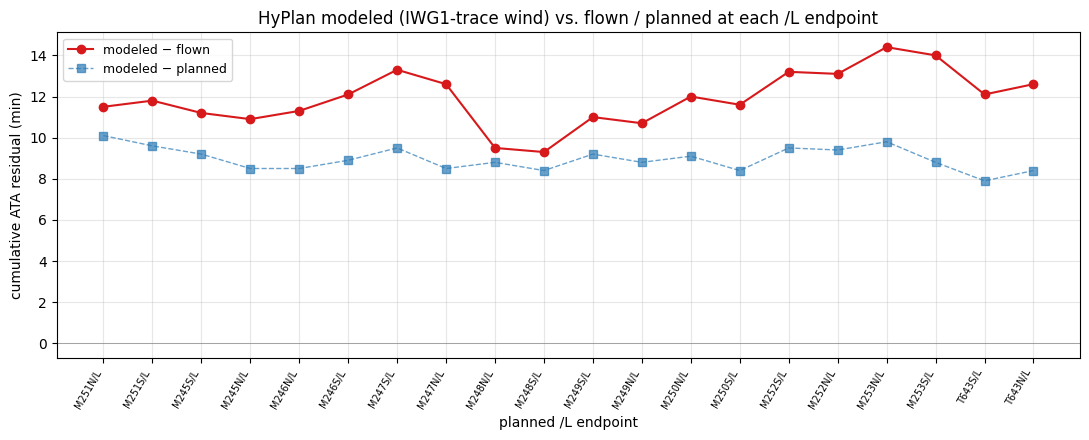

In [10]:
fig, ax = plt.subplots(figsize=(11, 4.5))
order = np.arange(len(ata_table))
ax.plot(order, ata_table["mod−flown"], "o-", color="#d7191c",
        lw=1.5, label="modeled − flown")
ax.plot(order, ata_table["mod−planned"], "s--", color="#2c7bb6",
        lw=1.0, alpha=0.7, label="modeled − planned")
ax.axhline(0, color="#888", lw=0.5)
ax.set_xticks(order)
ax.set_xticklabels(ata_table["fix_name"], rotation=60, ha="right", fontsize=7)
ax.set_xlabel("planned /L endpoint")
ax.set_ylabel("cumulative ATA residual (min)")
ax.set_title("HyPlan modeled (IWG1-trace wind) vs. flown / planned at each /L endpoint")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()

## 5. Top-of-climb / top-of-descent

Planned TOC/TOD positions: lat/lon of the planned event whose altitude crosses `MIN_CRUISE_ALT_FT` (interpolated within the bracketing two events). Flown TOC/TOD: first/last IWG1 fix at ≥ `MIN_CRUISE_ALT_FT`. Distances are great-circle from the departure airport (planned KCOS in the NM17 B case).

In [11]:
dep_lat = float(df.iloc[0]["lat_deg"]); dep_lon = float(df.iloc[0]["lon_deg"])
lat_arr = df["lat_deg"].to_numpy(); lon_arr = df["lon_deg"].to_numpy()

def _interp_position(idx_low, idx_high, alt_target):
    a0, a1 = alt[idx_low], alt[idx_high]
    if a1 == a0: return lat_arr[idx_low], lon_arr[idx_low]
    f = (alt_target - a0) / (a1 - a0)
    return (
        lat_arr[idx_low] + f * (lat_arr[idx_high] - lat_arr[idx_low]),
        lon_arr[idx_low] + f * (lon_arr[idx_high] - lon_arr[idx_low]),
    )

if first_high is not None and first_high > 0:
    p_toc_lat, p_toc_lon = _interp_position(first_high - 1, first_high, MIN_CRUISE_ALT_FT)
    p_toc_d_nmi = _haversine_km(dep_lat, dep_lon, p_toc_lat, p_toc_lon) / 1.852
else:
    p_toc_lat = p_toc_lon = float("nan"); p_toc_d_nmi = float("nan")
if last_high is not None and last_high < len(alt) - 1:
    p_tod_lat, p_tod_lon = _interp_position(last_high, last_high + 1, MIN_CRUISE_ALT_FT)
    p_tod_d_nmi = _haversine_km(dep_lat, dep_lon, p_tod_lat, p_tod_lon) / 1.852
else:
    p_tod_lat = p_tod_lon = float("nan"); p_tod_d_nmi = float("nan")

if fhi is not None:
    a_toc_lat = float(actual.loc[fhi, "latitude"]); a_toc_lon = float(actual.loc[fhi, "longitude"])
    a_toc_d_nmi = _haversine_km(dep_lat, dep_lon, a_toc_lat, a_toc_lon) / 1.852
else:
    a_toc_lat = a_toc_lon = float("nan"); a_toc_d_nmi = float("nan")
if lhi is not None:
    a_tod_lat = float(actual.loc[lhi, "latitude"]); a_tod_lon = float(actual.loc[lhi, "longitude"])
    a_tod_d_nmi = _haversine_km(dep_lat, dep_lon, a_tod_lat, a_tod_lon) / 1.852
else:
    a_tod_lat = a_tod_lon = float("nan"); a_tod_d_nmi = float("nan")

toc_tod = pd.DataFrame([
    {"metric": "toc_distance_from_departure_nmi", "planned": round(p_toc_d_nmi, 1), "flown": round(a_toc_d_nmi, 1)},
    {"metric": "toc_lat_deg",                     "planned": round(p_toc_lat, 4),  "flown": round(a_toc_lat, 4)},
    {"metric": "toc_lon_deg",                     "planned": round(p_toc_lon, 4),  "flown": round(a_toc_lon, 4)},
    {"metric": "tod_distance_from_departure_nmi", "planned": round(p_tod_d_nmi, 1), "flown": round(a_tod_d_nmi, 1)},
    {"metric": "tod_lat_deg",                     "planned": round(p_tod_lat, 4),  "flown": round(a_tod_lat, 4)},
    {"metric": "tod_lon_deg",                     "planned": round(p_tod_lon, 4),  "flown": round(a_tod_lon, 4)},
])
toc_tod.set_index("metric")

,planned,flown
metric,,
toc_distance_from_departure_nmi,43.0000,37.5000
toc_lat_deg,38.0933,38.1890
toc_lon_deg,-104.6002,-104.5789
tod_distance_from_departure_nmi,37.2000,54.8000
tod_lat_deg,38.1940,37.9669
tod_lon_deg,-104.5810,-104.2449


## 7. Ground-track comparison (planned / flown / HyPlan-modeled)

Three-panel side-by-side: planned KML route (waypoints + connector), as-flown IWG1 track (phase-colored), and HyPlan's modeled trajectory built from the FlightLine list extracted in §5 (segments colored by phase, Dubins turns visible between flight lines).

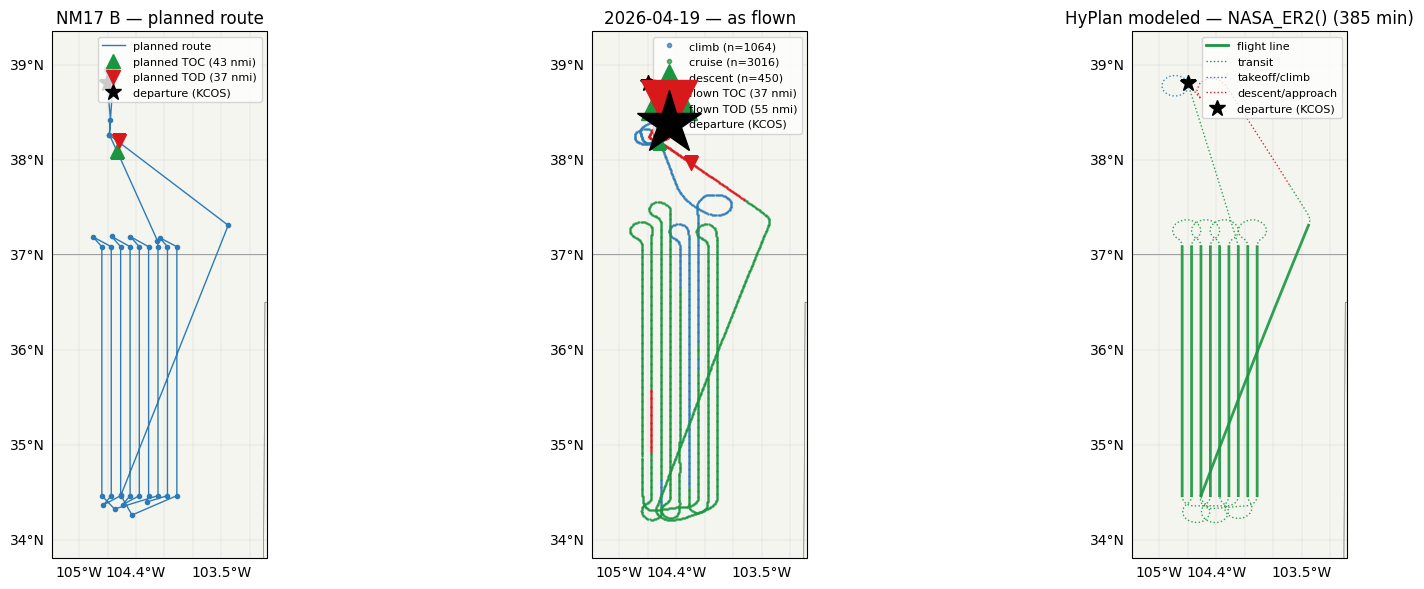

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6),
                          subplot_kw={"projection": ccrs.PlateCarree()})
extent = [
    min(actual["longitude"].min(), df["lon_deg"].min()) - 0.4,
    max(actual["longitude"].max(), df["lon_deg"].max()) + 0.4,
    min(actual["latitude"].min(),  df["lat_deg"].min())  - 0.4,
    max(actual["latitude"].max(),  df["lat_deg"].max())  + 0.4,
]
for ax in axes:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.STATES.with_scale("50m"), linewidth=0.4, edgecolor="#888")
    ax.add_feature(cfeature.LAND, facecolor="#f5f5f0")
    ax.add_feature(cfeature.OCEAN, facecolor="#dfe7f5")
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    gl.top_labels = False; gl.right_labels = False

ax_p, ax_a, ax_h = axes
phase_colors = {"climb": "#2c7bb6", "cruise": "#1a9641", "descent": "#d7191c"}

# Panel 1: planned KML route
wpt_only = df[df["kind"] == "waypoint"]
ax_p.plot(wpt_only["lon_deg"], wpt_only["lat_deg"], "-", lw=1.0, color="#2c7bb6",
          transform=ccrs.PlateCarree(), label="planned route")
ax_p.plot(wpt_only["lon_deg"], wpt_only["lat_deg"], "o", ms=3, color="#2c7bb6",
          transform=ccrs.PlateCarree())
ax_p.plot(p_toc_lon, p_toc_lat, "^", ms=10, color="#1a9641",
          transform=ccrs.PlateCarree(), label=f"planned TOC ({p_toc_d_nmi:.0f} nmi)")
ax_p.plot(p_tod_lon, p_tod_lat, "v", ms=10, color="#d7191c",
          transform=ccrs.PlateCarree(), label=f"planned TOD ({p_tod_d_nmi:.0f} nmi)")
ax_p.plot(dep_lon, dep_lat, "k*", ms=12, transform=ccrs.PlateCarree(),
          label=f"departure ({dep_icao})")
ax_p.set_title(f"{PLANNED_NAME} — planned route")
ax_p.legend(loc="upper right", fontsize=8)

# Panel 2: as-flown IWG1
for phase, color in phase_colors.items():
    sub = actual[actual["phase"] == phase]
    ax_a.plot(sub["longitude"], sub["latitude"], ".", ms=1.5, color=color, alpha=0.7,
              transform=ccrs.PlateCarree(), label=f"{phase} (n={len(sub)})")
ax_a.plot(a_toc_lon, a_toc_lat, "^", ms=10, color="#1a9641",
          transform=ccrs.PlateCarree(), label=f"flown TOC ({a_toc_d_nmi:.0f} nmi)")
ax_a.plot(a_tod_lon, a_tod_lat, "v", ms=10, color="#d7191c",
          transform=ccrs.PlateCarree(), label=f"flown TOD ({a_tod_d_nmi:.0f} nmi)")
ax_a.plot(dep_lon, dep_lat, "k*", ms=12, transform=ccrs.PlateCarree(),
          label=f"departure ({dep_icao})")
ax_a.set_title(f"{actual_takeoff.strftime('%Y-%m-%d')} — as flown")
ax_a.legend(loc="upper right", fontsize=8, markerscale=4)

# Panel 3: HyPlan modeled trajectory
seg_colors = {
    "takeoff":     phase_colors["climb"],
    "climb":       phase_colors["climb"],
    "transit":     phase_colors["cruise"],
    "flight_line": phase_colors["cruise"],
    "descent":     phase_colors["descent"],
    "approach":    phase_colors["descent"],
}
flight_line_handle = transit_handle = climb_handle = descent_handle = None
for _, seg in hyplan_plan.iterrows():
    g = seg["geometry"]
    if g is None or not hasattr(g, "coords"):
        continue
    xs, ys = zip(*g.coords)
    color = seg_colors.get(seg["segment_type"], "#444")
    lw = 2.0 if seg["segment_type"] == "flight_line" else 1.0
    ls = "-" if seg["segment_type"] == "flight_line" else ":"
    ax_h.plot(xs, ys, color=color, lw=lw, linestyle=ls, alpha=0.9,
              transform=ccrs.PlateCarree())
ax_h.plot([], [], color=phase_colors["cruise"], lw=2.0, linestyle="-", label="flight line")
ax_h.plot([], [], color=phase_colors["cruise"], lw=1.0, linestyle=":", label="transit")
ax_h.plot([], [], color=phase_colors["climb"],  lw=1.0, linestyle=":", label="takeoff/climb")
ax_h.plot([], [], color=phase_colors["descent"],lw=1.0, linestyle=":", label="descent/approach")
ax_h.plot(dep_lon, dep_lat, "k*", ms=12, transform=ccrs.PlateCarree(),
          label=f"departure ({dep_icao})")
hp_total = hyplan_plan["time_to_segment"].sum()
ax_h.set_title(f"HyPlan modeled — NASA_ER2() ({hp_total:.0f} min)")
ax_h.legend(loc="upper right", fontsize=8)

fig.tight_layout()

## 7. Altitude profile comparison

Planned altitude trace (step-altitudes from the Green Card events) overlaid on the IWG1 altitude trace. Step-cruise behavior — actual aircraft drifting up through level-offs as fuel burns off — shows clearly here.

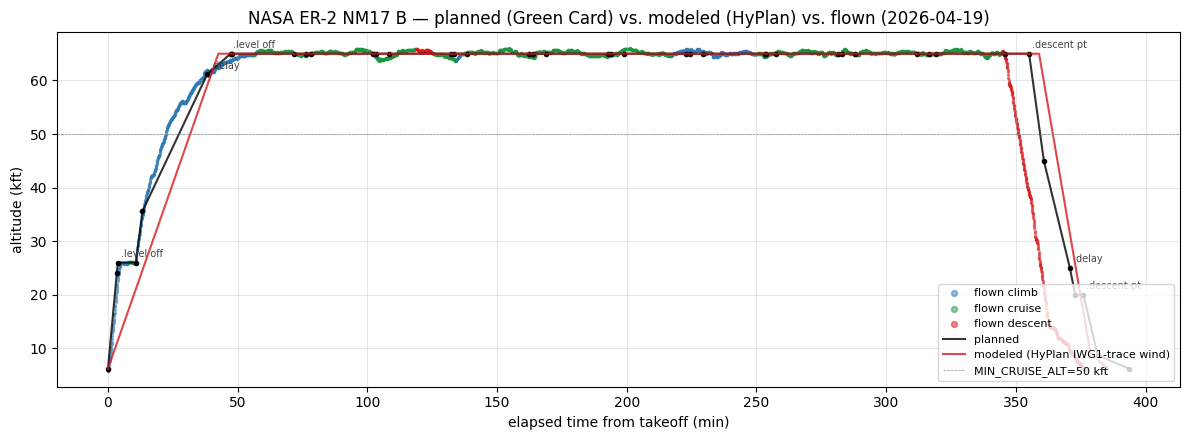

In [13]:
fig, ax = plt.subplots(figsize=(12, 4.5))

# Flown — IWG1 trace, phase-colored
elapsed = (actual["timestamp"] - actual_takeoff).dt.total_seconds() / 60.0
for phase, color in phase_colors.items():
    mask = actual["phase"] == phase
    if mask.any():
        ax.scatter(elapsed[mask], actual.loc[mask, "altitude"] / 1000.0,
                   s=2, c=color, alpha=0.5, label=f"flown {phase}")

# Planned — Green Card step-altitude trace
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "-", color="black", lw=1.5, alpha=0.8, label="planned")
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "o", color="black", ms=3)
for _, w in df[df["kind"].isin(["level_off", "delay", "descent_pt"])].iterrows():
    ax.annotate(
        w["fix_name"], xy=(w["cumulative_time_min"], w["altitude_ft"] / 1000.0),
        xytext=(2, 4), textcoords="offset points", fontsize=7, color="#444",
    )

# Modeled — HyPlan plan with IWG1-trace wind (§6).  Walk segments
# cumulatively and draw piecewise-linear start_altitude → end_altitude.
plan_for_alt = hyplan_plan_iwg1wind
mod_t = [0.0]
mod_alt = [float(plan_for_alt["start_altitude"].iloc[0]) / 1000.0]
cum = 0.0
for _, seg in plan_for_alt.iterrows():
    mod_t.append(cum)
    mod_alt.append(float(seg["start_altitude"]) / 1000.0)
    cum += float(seg["time_to_segment"])
    mod_t.append(cum)
    mod_alt.append(float(seg["end_altitude"]) / 1000.0)
ax.plot(mod_t, mod_alt, "-", color="#d7191c", lw=1.5, alpha=0.8,
        label="modeled (HyPlan IWG1-trace wind)")

ax.axhline(MIN_CRUISE_ALT_FT / 1000.0, color="#888", ls="--", lw=0.5,
           label=f"MIN_CRUISE_ALT={MIN_CRUISE_ALT_FT/1000:.0f} kft")
ax.set_xlabel("elapsed time from takeoff (min)")
ax.set_ylabel("altitude (kft)")
ax.set_title(
    f"NASA ER-2 {PLANNED_NAME} — planned (Green Card) vs. modeled (HyPlan) "
    f"vs. flown ({actual_takeoff.strftime('%Y-%m-%d')})"
)
ax.legend(loc="lower right", fontsize=8, markerscale=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## 8. Step-cruise altitude schedule

The +11.5 min residual on the climb-out (KCOS → first /L) and the small +1.1 min residual within the survey grid both come from the same structural gap: HyPlan models every flight line at a single altitude (FL650, the median of the planned cruise), while the real ER-2 climbs in *steps* — pre-survey it stages through BRK/E (FL240), PUB/R253012 (FL260), PUB/R206014 (FL356, plus a 25 min `.delay` orbit climbing to FL611), TBE/E245028 (FL650); on-station it drifts FL636 → FL655 across each flight line; on descent it stages through PUB/R253012 (FL450), PUB/R296014 (FL200), CEMKA/W (8.7 kft).

Two notebook-side fixes work together:

1. **Per-line altitude schedule** (in-survey step-climb): replace each `FlightLine`'s pinned altitude with the *median* altitude observed during the flown line traversal.  HyPlan's `_hybrid_path` distributes any climb between consecutive lines across the inter-line transit.

2. **Pre-/post-survey staging Waypoints** (climb-out / descent-in step-climb): insert the Green Card's intermediate navaid fixes as `Waypoint` objects in `flight_sequence`.  The sequence becomes ``[climb-out fixes…, FlightLines…, descent-in fixes…]``, so HyPlan plans transits at intermediate altitudes (FL240, FL260, FL356, …) instead of going straight to FL650 before the first line — and the spiral-up logic from `_hybrid_path` handles the unavoidable orbit at PUB/R206014 where the aircraft has to climb FL356 → FL611 in a fixed lat/lon.

In [14]:
import pymap3d.vincenty
from hyplan.waypoint import Waypoint


def _heading_to(lat1, lon1, lat2, lon2):
    """Forward azimuth (degrees) from (lat1, lon1) to (lat2, lon2)."""
    _, az = pymap3d.vincenty.vdist(lat1, lon1, lat2, lon2)
    return float(az)


# --- 1. Per-line altitude schedule (median IWG1 altitude per /L pair) ---
elapsed = (actual["timestamp"] - actual_takeoff).dt.total_seconds() / 60.0
flown_ata = fix_table.set_index("wp_num")["flown_ata_min"]

stepped_flight_lines = []
schedule_rows = []
for i, fl in enumerate(flight_lines):
    wp_in = int(endpoints_only.iloc[2 * i]["wp_num"])
    wp_out = int(endpoints_only.iloc[2 * i + 1]["wp_num"])
    t_in = flown_ata.get(wp_in, float("nan"))
    t_out = flown_ata.get(wp_out, float("nan"))
    if pd.isna(t_in) or pd.isna(t_out) or t_out <= t_in:
        new_alt = fl.altitude_msl
        median_alt_ft = float(fl.altitude_msl.m_as(ureg.foot))
    else:
        mask = (elapsed >= t_in) & (elapsed <= t_out)
        if mask.any():
            median_alt_ft = float(actual.loc[mask, "altitude"].median())
            new_alt = ureg.Quantity(median_alt_ft, "feet")
        else:
            new_alt = fl.altitude_msl
            median_alt_ft = float(fl.altitude_msl.m_as(ureg.foot))
    stepped_flight_lines.append(FlightLine.from_endpoints(
        lat1=fl.waypoint1.latitude, lon1=fl.waypoint1.longitude,
        lat2=fl.waypoint2.latitude, lon2=fl.waypoint2.longitude,
        altitude_msl=new_alt,
        site_name=fl.site_name,
    ))
    schedule_rows.append({
        "site": fl.site_name,
        "flat_alt_ft": int(round(fl.altitude_msl.m_as(ureg.foot))),
        "stepped_alt_ft": int(round(median_alt_ft)),
    })


# --- 2. Pre-/post-survey staging Waypoints from Green Card ---
first_l_order = int(endpoints_only["order"].iloc[0])
last_l_order = int(endpoints_only["order"].iloc[-1])

climb_out_fixes = planned.waypoints[
    (planned.waypoints["order"] > 1)
    & (planned.waypoints["order"] < first_l_order)
    & (planned.waypoints["kind"] == "waypoint")
    & (~planned.waypoints["fix_name"].str.endswith("/A"))
].reset_index(drop=True)

descent_in_fixes = planned.waypoints[
    (planned.waypoints["order"] > last_l_order)
    & (planned.waypoints["kind"] == "waypoint")
    & (~planned.waypoints["fix_name"].str.endswith("/A"))
].reset_index(drop=True)


def _build_staging(fixes, follow_lat, follow_lon):
    """Build Waypoints, headings pointing toward the next item in the sequence."""
    out = []
    for i, row in fixes.iterrows():
        if i + 1 < len(fixes):
            nxt = fixes.iloc[i + 1]
            n_lat, n_lon = float(nxt["lat_deg"]), float(nxt["lon_deg"])
        else:
            n_lat, n_lon = follow_lat, follow_lon
        out.append(Waypoint(
            latitude=float(row["lat_deg"]),
            longitude=float(row["lon_deg"]),
            heading=_heading_to(row["lat_deg"], row["lon_deg"], n_lat, n_lon),
            altitude_msl=ureg.Quantity(float(row["altitude_ft"]), "feet"),
        ))
    return out


first_l_lat = float(endpoints_only.iloc[0]["lat_deg"])
first_l_lon = float(endpoints_only.iloc[0]["lon_deg"])
last_l_lat = float(endpoints_only.iloc[-1]["lat_deg"])
last_l_lon = float(endpoints_only.iloc[-1]["lon_deg"])

climb_wps = _build_staging(climb_out_fixes, first_l_lat, first_l_lon)
descent_wps = _build_staging(descent_in_fixes, departure.latitude, departure.longitude)


# --- 3. Build three plan variants ---
# (a) flat: per-line FL650, no staging  (== §6 baseline; just relabel)
# (b) stepped: per-line altitude schedule, no staging
# (c) staged: per-line schedule + pre/post-survey Green Card waypoints
hyplan_plan_stepped = compute_flight_plan(
    aircraft=aircraft, flight_sequence=stepped_flight_lines,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0, wind_source=iwg1_wind,
)
hyplan_plan_staged = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=climb_wps + stepped_flight_lines + descent_wps,
    takeoff_airport=departure, return_airport=arrival,
    start_offset=0, end_offset=0, wind_source=iwg1_wind,
)

print(f"climb-out staging   : {len(climb_wps)} waypoints from Green Card "
      f"({', '.join(r['fix_name'] for _, r in climb_out_fixes.iterrows())})")
print(f"descent-in staging  : {len(descent_wps)} waypoints from Green Card "
      f"({', '.join(r['fix_name'] for _, r in descent_in_fixes.iterrows())})")
print()
print(f"hyplan flat   (FL650 every line, no staging)  : "
      f"{hyplan_plan_iwg1wind['time_to_segment'].sum():.1f} min")
print(f"hyplan stepped (per-line IWG1 schedule)        : "
      f"{hyplan_plan_stepped['time_to_segment'].sum():.1f} min")
print(f"hyplan staged  (stepped + GC pre/post waypts)  : "
      f"{hyplan_plan_staged['time_to_segment'].sum():.1f} min")
print(f"flown total                                     : "
      f"{actual_total_min:.1f} min")
print(f"planned total                                   : "
      f"{planned_total_min:.1f} min")
print()
print("per-line altitude schedule:")
print(pd.DataFrame(schedule_rows).to_string(index=False))

climb-out staging   : 4 waypoints from Green Card (BRK/E, PUB/R253012, PUB/R206014, TBE/E245028)
descent-in staging  : 3 waypoints from Green Card (PUB/R253012, PUB/R296014, CEMKA/W)

hyplan flat   (FL650 every line, no staging)  : 385.5 min
hyplan stepped (per-line IWG1 schedule)        : 385.0 min
hyplan staged  (stepped + GC pre/post waypts)  : 405.8 min
flown total                                     : 377.5 min
planned total                                   : 393.6 min

per-line altitude schedule:
site  flat_alt_ft  stepped_alt_ft
M251        65000           65165
M245        65000           65260
M246        65000           65391
M247        65000           65270
M248        65000           65229
M249        65000           65165
M250        65000           65081
M252        65000           65172
M253        65000           65180
T643        65000           65159


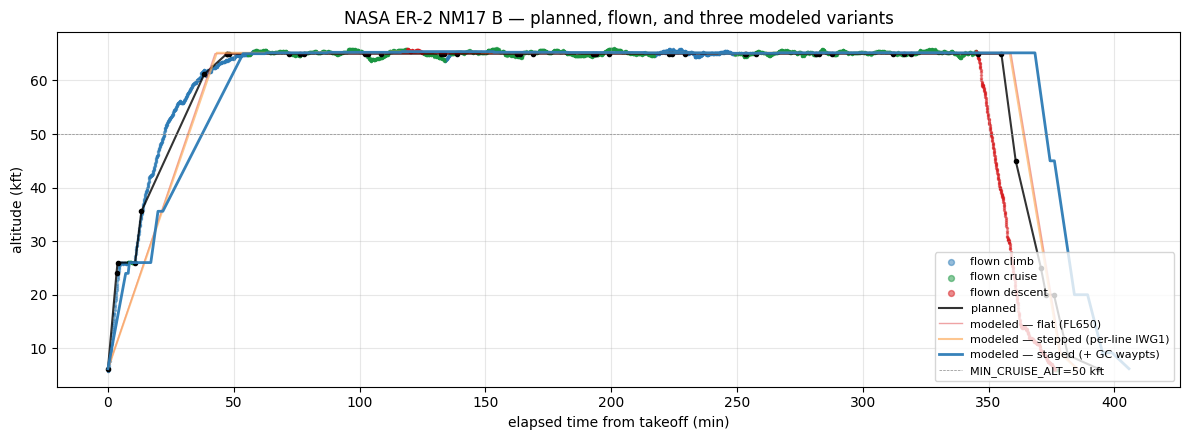

In [15]:
# Re-render the altitude profile with stepped-modeled and staged-modeled overlays.
fig, ax = plt.subplots(figsize=(12, 4.5))

# Flown — IWG1 trace, phase-colored.
for phase, color in phase_colors.items():
    mask = actual["phase"] == phase
    if mask.any():
        ax.scatter(elapsed[mask], actual.loc[mask, "altitude"] / 1000.0,
                   s=2, c=color, alpha=0.5, label=f"flown {phase}")

# Planned — Green Card step-altitude.
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "-", color="black", lw=1.5, alpha=0.8, label="planned")
ax.plot(df["cumulative_time_min"], df["altitude_ft"] / 1000.0,
        "o", color="black", ms=3)


def _trace(plan):
    t, a, cum = [0.0], [float(plan["start_altitude"].iloc[0]) / 1000.0], 0.0
    for _, seg in plan.iterrows():
        t.append(cum); a.append(float(seg["start_altitude"]) / 1000.0)
        cum += float(seg["time_to_segment"])
        t.append(cum); a.append(float(seg["end_altitude"]) / 1000.0)
    return t, a


for plan, color, alpha, label, lw, ls in [
    (hyplan_plan_iwg1wind, "#d7191c", 0.4, "modeled — flat (FL650)",            1.0, "-"),
    (hyplan_plan_stepped,  "#fdae61", 0.7, "modeled — stepped (per-line IWG1)", 1.5, "-"),
    (hyplan_plan_staged,   "#2c7bb6", 0.95, "modeled — staged (+ GC waypts)",   2.0, "-"),
]:
    t, a = _trace(plan)
    ax.plot(t, a, ls, color=color, lw=lw, alpha=alpha, label=label)

ax.axhline(MIN_CRUISE_ALT_FT / 1000.0, color="#888", ls="--", lw=0.5,
           label=f"MIN_CRUISE_ALT={MIN_CRUISE_ALT_FT/1000:.0f} kft")
ax.set_xlabel("elapsed time from takeoff (min)")
ax.set_ylabel("altitude (kft)")
ax.set_title(
    f"NASA ER-2 {PLANNED_NAME} — planned, flown, and three modeled variants"
)
ax.legend(loc="lower right", fontsize=8, markerscale=3)
ax.grid(alpha=0.3)
fig.tight_layout()

## 9. Multi-pair scan (all in-scope pairs)

NM17 B is one of three pairs cataloged in [PAIRS.md](PAIRS.md).  Re-run the same `compute_flight_plan` pipeline (per-line FL650 altitudes, `start_offset=0` / `end_offset=0`, `IWG1TraceWindField` per pair) against CO07v4 and CO06 — both PDF Green Cards, both validated end-to-end through `parse_green_card_pdf` — and tabulate the planned / flown / modeled totals.

In [16]:
from hyplan.aircraft import load_planned_sortie as _load_planned

PAIRS_TO_SCAN = [
    {
        "name": "NM17 B",
        "kml":  DATA_DIR / "NM17 B KML.kml",
        "gc":   DATA_DIR / "NM17 B ER2 Green Card1.xlsx",
        "iwg1": DATA_DIR / "69e4e6e92706ae3e20f884fd.txt",
    },
    {
        "name": "CO07v4",
        "kml":  DATA_DIR / "CO07v4 KML.kml",
        "gc":   DATA_DIR / "CO07v4 ER2 Green Card1.pdf",
        "iwg1": DATA_DIR / "69e78230620db03dc45a5c05.txt",
    },
    {
        "name": "CO06",
        "kml":  DATA_DIR / "CO06 KML.kml",
        "gc":   DATA_DIR / "CO06 ER2 Green Card1.pdf",
        "iwg1": DATA_DIR / "69eb6b075886b06d1bd1a7c6.txt",
    },
]


def _scan_one_pair(pair):
    p = _load_planned(pair["kml"], pair["gc"])
    raw = load_iwg1(pair["iwg1"])
    a = trim_ground_taxi(raw)
    flown_total = (a["timestamp"].iloc[-1] - a["timestamp"].iloc[0]).total_seconds() / 60.0
    planned_total = float(p.waypoints["cumulative_time_min"].iloc[-1])

    end = (
        p.waypoints[p.waypoints["fix_name"].str.endswith("/L")]
        .reset_index(drop=True)
    )
    fls = []
    for i in range(0, len(end) - 1, 2):
        ai, bi = end.iloc[i], end.iloc[i + 1]
        if pd.isna(ai["lat_deg"]) or pd.isna(bi["lat_deg"]):
            continue
        fls.append(FlightLine.from_endpoints(
            lat1=float(ai["lat_deg"]), lon1=float(ai["lon_deg"]),
            lat2=float(bi["lat_deg"]), lon2=float(bi["lon_deg"]),
            altitude_msl=ureg.Quantity(float(ai["altitude_ft"]), "feet"),
            site_name=_line_id(ai["fix_name"], bi["fix_name"]),
        ))
    airport_rows = p.waypoints[p.waypoints["fix_name"].str.endswith("/A")]
    dep = Airport(airport_rows.iloc[0]["fix_name"].removesuffix("/A"))
    arr = Airport(airport_rows.iloc[-1]["fix_name"].removesuffix("/A"))

    plan = compute_flight_plan(
        aircraft=NASA_ER2(), flight_sequence=fls,
        takeoff_airport=dep, return_airport=arr,
        start_offset=0, end_offset=0,
        wind_source=IWG1TraceWindField(a),
    )
    modeled_total = float(plan["time_to_segment"].sum())
    return {
        "pair": pair["name"],
        "lines": len(fls),
        "dep/arr": f"{dep.icao_code}/{arr.icao_code}",
        "planned_min": round(planned_total, 1),
        "flown_min":   round(flown_total, 1),
        "modeled_min": round(modeled_total, 1),
        "mod−flown_min":  round(modeled_total - flown_total, 1),
        "mod−flown_pct":  round((modeled_total - flown_total) / flown_total * 100, 1),
        "mod−planned_min": round(modeled_total - planned_total, 1),
    }


scan = pd.DataFrame([_scan_one_pair(p) for p in PAIRS_TO_SCAN])
print(scan.to_string(index=False))

  pair  lines   dep/arr  planned_min  flown_min  modeled_min  mod−flown_min  mod−flown_pct  mod−planned_min
NM17 B     10 KCOS/KCOS        393.6      377.5        385.5            8.0            2.1             -8.1
CO07v4      8 KCOS/KCOS        313.6      287.0        309.5           22.5            7.9             -4.1
  CO06      6 KCOS/KCOS        268.9      261.9        265.7            3.8            1.4             -3.2


## 8. What this tells us

Driven by §3, §4, §5:

* **Mission-level residual** (planned vs. flown total / TOC / on-station / descent): see §3.
* **Step-cruise visibility**: §7's altitude overlay should show the actual aircraft drifting up through the planned level-offs — that's the structural gap.
* **TOC/TOD location residual** (§5): a meaningful planned-vs-flown gap here implies the *plan itself* assumed different climb/descent kinematics than the aircraft actually flew, distinct from any HyPlan modeling error.
* **Fix-by-fix timing residual** (§4): if `delta_min` grows monotonically through the survey, that points at a TAS/wind miscalibration rather than a one-off departure-or-approach delay.

Once CO06 and CO07v4 come online (PDF Green Card parser), this same notebook should run for all three pairs by swapping the parameters in the setup cell. Cross-pair findings will go into `PLANNED_VS_FLOWN.md` as the deliverable.